In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

cwd = Path.cwd()
# Load dotenv into sys PATH
dotenv_file = cwd / "../../../example/.env"
assert dotenv_file.is_file()
load_dotenv(dotenv_file)

True

In [2]:
from py_madaclim.raster_manipulation import MadaclimCollection
from py_madaclim.info import MadaclimLayers
from py_madaclim.raster_manipulation import MadaclimRasters
from pathlib import Path

mada_info = MadaclimLayers()

raster_files = ["madaclim_current.tif", "madaclim_enviro.tif"]
if not all([(cwd / raster_file).exists() for raster_file in raster_files]):
    mada_info.download_data(save_dir=cwd)

mada_info.clim_raster = "./madaclim_current.tif"
mada_info.env_raster = "./madaclim_enviro.tif"


cwd = Path.cwd()
mada_rasters = MadaclimRasters(clim_raster=cwd / "madaclim_current.tif", env_raster=cwd / "madaclim_enviro.tif")

clim_labels =  [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "clim" in label]
env_labels = [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "env" in label]


####   Trying get request to Madaclim website...   ####
madaclim_current.tif is 21.8 MB
Server response OK from madaclim.cirad.fr, starting to download madaclim_current.tif
Progress for madaclim_current.tif : 100.00 % completed of 21.8 MB downloaded [ average speed of  1.1 MB/s ]
Done downloading madaclim_current.tif in 20.00 seconds !

####   Trying get request to Madaclim website...   ####
madaclim_enviro.tif is 5.5 MB
Server response OK from madaclim.cirad.fr, starting to download madaclim_enviro.tif
Progress for madaclim_enviro.tif : 100.00 % completed of 5.5 MB downloaded [ average speed of  1.6 MB/s ]
Done downloading madaclim_enviro.tif in 3.50 seconds !


In [3]:
import re
# Functions to extract part of the specimen_id for matching

def extract_name(specimen_id):
    # Ensure the input is a string and remove leading/trailing underscores or spaces
    if isinstance(specimen_id, str):
        specimen_id = specimen_id.strip('_ ').strip()
        # Split by either an underscore or space, and take the first part
        split_result = re.split(r'[_\s]', specimen_id)
        return split_result[0] if split_result else specimen_id
    return specimen_id



def extract_id(specimen_id):
    # Use regex to extract the part of the string after the last underscore
    match = re.search(r'_(\w+)$', specimen_id)
    if match:
        return match.group(1)  # Return the ID after the underscore
    return None  # Return None if no match is found




Extract and format data obtained from gbif in view of MadaclimCollection creation

In [4]:
import pandas as pd
csv_file = r"../../../example/gbif_example\0026013-240906103802322\0026013-240906103802322.csv"
coff_dl_df = pd.read_csv(csv_file, sep='\t')

In [5]:
df = coff_dl_df.loc[coff_dl_df["taxonRank"] == "SPECIES"]
df = df.loc[df["countryCode"] == "MG"]
df = df.loc[:, ["verbatimScientificName", "decimalLongitude", "decimalLatitude", "year"]]
df = df.reset_index().drop(columns="index")
df["specimen_id"] = df.apply(lambda row: f"{row['verbatimScientificName']}_{row.name}", axis=1)
df["specimen_id"] = df["specimen_id"].str.strip("Coffea")
df["specimen_id"] = df["specimen_id"].str.strip("Psilanthus")
df.columns = ["genus_species", "longitude", "latitude", "year", "specimen_id"]
print(df.shape)
df.head()

(2837, 5)


,genus_species,longitude,latitude,year,specimen_id
0,Coffea antsingyensis,NaN,NaN,1959.0,antsingyensis_0
1,Coffea toshii,46.891944,-22.473333,2006.0,toshii_1
2,Coffea ambongensis,45.335000,-16.121389,2000.0,ambongensis_2
3,Coffea ambongensis,46.416667,-15.577500,2000.0,ambongensis_3
4,Coffea humbertii,43.797500,-22.875000,2004.0,humbertii_4


In [7]:
#no wrapping
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping
pd.set_option('display.max_rows', None)


In [8]:

df_mada = coff_dl_df[coff_dl_df["countryCode"] == "MG"]

year_counts = df_mada.groupby('year').size()

print(year_counts)

year
1770.0      1
1841.0     15
1848.0      2
1866.0      2
1872.0      1
1879.0     11
1886.0      3
1894.0      1
1899.0      6
1900.0      1
1902.0      2
1903.0      4
1905.0      5
1906.0      9
1912.0      5
1923.0      8
1924.0      1
1928.0      9
1932.0     13
1933.0      1
1938.0      1
1940.0      9
1945.0     12
1946.0      5
1947.0      7
1949.0      7
1950.0     15
1952.0     21
1953.0     27
1954.0     14
1955.0     19
1956.0     14
1957.0      9
1958.0     28
1959.0      8
1960.0     11
1961.0     10
1962.0     70
1963.0     77
1964.0     51
1965.0     12
1966.0     59
1967.0     30
1968.0      7
1969.0     11
1970.0     21
1971.0     12
1972.0      2
1973.0      2
1974.0      2
1975.0      3
1978.0      2
1980.0      4
1981.0      4
1983.0      1
1985.0      6
1986.0      1
1987.0     19
1988.0     14
1989.0     46
1990.0     24
1991.0      9
1992.0     27
1993.0     42
1994.0     25
1995.0     11
1996.0     43
1997.0     58
1998.0     79
1999.0    333
2000.0     98
2

In [11]:
# Last 6 years
df_2018_p = df.loc[df["year"] > 2018.0]
print(len(df_2018_p))
print(df_2018_p.head())

94
                                  genus_species  longitude   latitude    year                               specimen_id
260                         Coffea mangoroensis  48.469736 -18.945639  2024.0                          mangoroensis_260
261  Coffea perrieri Drake ex Jum. & H. Perrier  46.333889 -24.560833  2024.0   perrieri Drake ex Jum. & H. Perrier_261
262  Coffea perrieri Drake ex Jum. & H. Perrier  46.333889 -24.560833  2024.0   perrieri Drake ex Jum. & H. Perrier_262
263  Coffea perrieri Drake ex Jum. & H. Perrier  46.333889 -24.560833  2024.0   perrieri Drake ex Jum. & H. Perrier_263
265                       Coffea tricalysioides  48.964722 -14.203611  2022.0                        tricalysioides_265


In [12]:
# Last 24 years
df_2000 = df.loc[df["year"] > 2000]
print(len(df_2000))
print(df_2000.head())

1185
       genus_species  longitude   latitude    year    specimen_id
1      Coffea toshii  46.891944 -22.473333  2006.0       toshii_1
4   Coffea humbertii  43.797500 -22.875000  2004.0    humbertii_4
9   Coffea boinensis  46.801111 -16.319444  2002.0    boinensis_9
18  Coffea bissetiae  46.805278 -16.328889  2002.0   bissetiae_18
20  Coffea bissetiae  46.432222 -15.588889  2002.0   bissetiae_20


Using data specimens with geolocation coordinates extracted from GBIF since 2000, a collection will be created for 
$\textcolor{yellow}{ALL}$ specimens in Madagascar (countryCode = MG) in view of attribute analysis

In [66]:
import sys
import os
import re
import pandas as pd


df_all = df_2000[['specimen_id', 'longitude', 'latitude']].copy() 

df_all['key'] = df_all['specimen_id'].apply(extract_name)
df_all['extracted_id'] = df_all['specimen_id'].apply(extract_id)
df_all['specimen_id'] = df_all['key'] + '_' + df_all['extracted_id']

df_all = df_all.drop(['key', 'extracted_id'], axis=1)
df_all = df_all.dropna(subset=['longitude'])

df_all.to_csv(r"../data/gbif_mada_all_for_collection.csv")
#df_2000.to_csv()


In [67]:
df_all.shape

(1104, 3)

Creation of collection with all MG data

In [105]:
from py_madaclim.raster_manipulation import MadaclimCollection
coll_all = MadaclimCollection.populate_from_df(df_all)
coll_all_clim = MadaclimCollection.populate_from_df(df_all)
coll_all_env = MadaclimCollection.populate_from_df(df_all)
coll_all.gdf

Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=toshii_1...)
Creating MadaclimPoint(specimen_id=humbertii_4...)
Creating MadaclimPoint(specimen_id=boinensis_9...)
Creating MadaclimPoint(specimen_id=bissetiae_18...)
Creating MadaclimPoint(specimen_id=bissetiae_20...)
Creating MadaclimPoint(specimen_id=bissetiae_32...)
Creating MadaclimPoint(specimen_id=commersoniana_42...)
Creating MadaclimPoint(specimen_id=commersoniana_111...)
Creating MadaclimPoint(specimen_id=commersoniana_112...)
Creating MadaclimPoint(specimen_id=commersoniana_113...)
Creating MadaclimPoint(specimen_id=labatii_122...)
Creating MadaclimPoint(specimen_id=liaudii_123...)
Creating MadaclimPoint(specimen_id=toshii_249...)
Creating MadaclimPoint(specimen_id=richardii_256...)
Creating MadaclimPoint(specimen_id=mangoroensis_260...)
Creating MadaclimPoint(specimen_id=perrieri_261...)
Creating MadaclimPoint(specimen_id=perrieri_262...)
Creating MadaclimPoin

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded
0,toshii_1,4326,46.891944,-22.473333,POINT (694658.563 7513551.374),None,None,False
1,humbertii_4,4326,43.797500,-22.875000,POINT (376646.419 7469814.361),None,None,False
2,boinensis_9,4326,46.801111,-16.319444,POINT (692421.416 8194878.943),None,None,False
3,bissetiae_18,4326,46.805278,-16.328889,POINT (692857.462 8193829.779),None,None,False
4,bissetiae_20,4326,46.432222,-15.588889,POINT (653558.855 8276022.724),None,None,False
...,...,...,...,...,...,...,...,...
1099,buxifolia_2815,4326,47.250000,-21.250000,POINT (733492.786 7648521.536),None,None,False
1100,buxifolia_2818,4326,46.632980,-20.595751,POINT (670183.875 7721737.373),None,None,False
1101,mogenetii_2820,4326,49.166670,-12.516670,POINT (953062.125 8612738.027),None,None,False
1102,decaryana_2821,4326,49.166670,-12.950000,POINT (952290.795 8564703.283),None,None,False


In [79]:
from py_madaclim.info import MadaclimLayers
mada_info = MadaclimLayers()
mada_info.all_layers

,geoclim_type,layer_number,layer_name,layer_description,is_categorical,units
0,clim,1,tmin1,Monthly minimum temperature - January,False,°C x 10
1,clim,2,tmin2,Monthly minimum temperature - February,False,°C x 10
2,clim,3,tmin3,Monthly minimum temperature - March,False,°C x 10
3,clim,4,tmin4,Monthly minimum temperature - April,False,°C x 10
4,clim,5,tmin5,Monthly minimum temperature - May,False,°C x 10
...,...,...,...,...,...,...
74,env,75,geo,Rock types,True,"[1=Alluvial_&_Lake_deposits, 2=Unconsolidated_..."
75,env,76,soi,Soil types,True,"[1=Bare_Rocks, 2=Raw_Lithic_Mineral_Soils, 3=P..."
76,env,77,veg,Vegetation types,True,"[1=VegCat_01, 2=VegCat_02, 3=VegCat_03, 4=VegC..."
77,env,78,wat,Watersheds,True,"[1=CoE_N-Bemarivo, 2=CoE_S-Bemarivo_N-Mangoro,..."


In [10]:
raster_files = ["madaclim_current.tif", "madaclim_enviro.tif"]
if not all([(cwd / raster_file).exists() for raster_file in raster_files]):
    mada_info.download_data(save_dir=cwd)


In [81]:

mada_info.clim_raster = "./madaclim_current.tif"
mada_info.env_raster = "./madaclim_enviro.tif"
print(mada_info)    # Now the 'get_bandnums_from_layers' is visible

MadaclimLayers(
	all_layers = DataFrame(79 rows x 6 columns)
	categorical_layers = DataFrame(Layers 75, 76, 77, 78 with a total of 79 categories
	clim_raster = madaclim_current.tif
	clim_crs = EPSG:32738
	env_raster = madaclim_enviro.tif
	env_crs = EPSG:32738
	public methods -> download_data, fetch_specific_layers, get_bandnums_from_layers
			 get_categorical_combinations, get_layers_labels, select_geoclim_type_layers
)


In [82]:
from py_madaclim.raster_manipulation import MadaclimRasters
from pathlib import Path
cwd = Path.cwd()
mada_rasters = MadaclimRasters(clim_raster=cwd / "madaclim_current.tif", env_raster=cwd / "madaclim_enviro.tif")
print(mada_rasters)

MadaclimRasters(
	clim_raster = madaclim_current.tif,
	clim_crs = EPSG:32738,
	clim_nodata_val = -32768.0
	env_raster = madaclim_enviro.tif,
	env_crs = EPSG:32738,
	env_nodata_val = -32768.0
)


In [110]:
clim_labels =  [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "clim" in label]
env_labels = [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "env" in label]

print("clim_labels", len(clim_labels),clim_labels)
print("env_labels",len(env_labels),env_labels)



clim_labels 70 ['clim_1_tmin1_Monthly minimum temperature - January (°C x 10)', 'clim_2_tmin2_Monthly minimum temperature - February (°C x 10)', 'clim_3_tmin3_Monthly minimum temperature - March (°C x 10)', 'clim_4_tmin4_Monthly minimum temperature - April (°C x 10)', 'clim_5_tmin5_Monthly minimum temperature - May (°C x 10)', 'clim_6_tmin6_Monthly minimum temperature - June (°C x 10)', 'clim_7_tmin7_Monthly minimum temperature - July (°C x 10)', 'clim_8_tmin8_Monthly minimum temperature - August (°C x 10)', 'clim_9_tmin9_Monthly minimum temperature - September (°C x 10)', 'clim_10_tmin10_Monthly minimum temperature - October (°C x 10)', 'clim_11_tmin11_Monthly minimum temperature - November (°C x 10)', 'clim_12_tmin12_Monthly minimum temperature - December (°C x 10)', 'clim_13_tmax1_Monthly maximum temperature - January (°C x 10)', 'clim_14_tmax2_Monthly maximum temperature - February (°C x 10)', 'clim_15_tmax3_Monthly maximum temperature - March (°C x 10)', 'clim_16_tmax4_Monthly max

In [ ]:


coll_all.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layer_info = True
)

In [ ]:
coll_all_clim.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layers_to_sample = clim_labels,
    layer_info = True
)


In [ ]:
coll_all_env.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layers_to_sample = env_labels,
    layer_info = True
)


In [91]:
coll_all.gdf.to_csv(r'../data/coll_all.csv', index=False)


In [113]:
coll_all_clim.gdf.to_csv(r'../data/coll_all_clim.csv', index=False)
coll_all_env.gdf.to_csv(r'../data/coll_all_env.csv', index=False)


Using data specimens with geolocation coordinates extracted from GBIF since 2000 including only the nodes for which we have phylogenetic information - not useful in data analysis but may be useful for graphs

In [74]:
import sys
import os
import re
import pandas as pd


df_gbif = df_2000[['specimen_id', 'longitude', 'latitude']].copy()  # Use .copy() to avoid warnings
df_node = pd.read_csv(r"..\..\input\node_names.csv")


# Apply extraction function to both DataFrames
df_gbif['key'] = df_gbif['specimen_id'].apply(extract_name)
#df_gbif.loc[:, 'key'] = df_gbif['specimen_id'].apply(extract_name)  # Use .loc to avoid SettingWithCopyWarning
df_node.loc[:, 'key'] = df_node['node_name'].apply(lambda x: re.sub(r'^C_|_[\dA-Za-z]+$', '', x))

# Create a dictionary for mapping key to Node Name
mapping = df_node.set_index('key')['node_name'].to_dict()

df_gbif['extracted_id'] = df_gbif['specimen_id'].apply(extract_id)

# Map the Node Name into a new column in df_gbif
df_gbif.loc[:, 'node_name'] = df_gbif['key'].map(mapping)

# Create the new specimen_id by concatenating key and extracted_id with an underscore
df_gbif['specimen_id'] = df_gbif['key'] + '_' + df_gbif['extracted_id']

# Alternatively, if you need to handle missing values in extracted_id (e.g., NaNs), you can do:
# df_gbif['specimen_id'] = df_gbif.apply(lambda row: f"{row['key']}_{row['extracted_id']}" if pd.notnull(row['extracted_id']) else row['key'], axis=1)


# # Drop the key column (optional)
df_gbif.drop(columns='key', inplace=True)

# # Drop rows where 'Node Name' is NaN
df_gbif.dropna(subset=['node_name'], inplace=True)

# # Select the final columns
df_new = df_gbif[['specimen_id', 'longitude', 'latitude']].copy()

# # Renaming columns
#df_new.rename(columns={'node_name': 'specimen_id'}, inplace=True)
df_new.dropna(subset=['longitude'], inplace=True)

# # Save the DataFrame to a new CSV
# #base_name, extension = os.path.splitext(csv_file)
# #formatted_csv_file = base_name + '_formatted' + extension
formatted_csv_file = r"../data/gbif_mada_all_nodes_for_collection.csv"
df_new.to_csv(formatted_csv_file, index=False)

print(f"Data saved to {formatted_csv_file}")
#pd.set_option('display.max_rows', None)
#print(df_gbif.sort_values(by='specimen_id'))
#print(df_node)




Data saved to ../data/gbif_mada_all_nodes_for_collection.csv


In [75]:
coll_tree_node = MadaclimCollection.populate_from_df(df_new)
coll_tree_node.gdf

Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=humbertii_4...)
Creating MadaclimPoint(specimen_id=boinensis_9...)
Creating MadaclimPoint(specimen_id=bissetiae_18...)
Creating MadaclimPoint(specimen_id=bissetiae_20...)
Creating MadaclimPoint(specimen_id=bissetiae_32...)
Creating MadaclimPoint(specimen_id=labatii_122...)
Creating MadaclimPoint(specimen_id=liaudii_123...)
Creating MadaclimPoint(specimen_id=richardii_256...)
Creating MadaclimPoint(specimen_id=perrieri_261...)
Creating MadaclimPoint(specimen_id=perrieri_262...)
Creating MadaclimPoint(specimen_id=perrieri_263...)
Creating MadaclimPoint(specimen_id=resinosa_264...)
Creating MadaclimPoint(specimen_id=resinosa_268...)
Creating MadaclimPoint(specimen_id=resinosa_269...)
Creating MadaclimPoint(specimen_id=humbertii_270...)
Creating MadaclimPoint(specimen_id=mcphersonii_272...)
Creating MadaclimPoint(specimen_id=richardii_274...)
Creating MadaclimPoint(specimen_i

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded
0,humbertii_4,4326,43.797500,-22.875000,POINT (376646.419 7469814.361),None,None,False
1,boinensis_9,4326,46.801111,-16.319444,POINT (692421.416 8194878.943),None,None,False
2,bissetiae_18,4326,46.805278,-16.328889,POINT (692857.462 8193829.779),None,None,False
3,bissetiae_20,4326,46.432222,-15.588889,POINT (653558.855 8276022.724),None,None,False
4,bissetiae_32,4326,46.801111,-16.319444,POINT (692421.416 8194878.943),None,None,False
...,...,...,...,...,...,...,...,...
704,ratsimamangae_2810,4326,49.450000,-13.130000,POINT (982749.988 8544223.119),None,None,False
705,mcphersonii_2811,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),None,None,False
706,dubardii_2812,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),None,None,False
707,dubardii_2813,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),None,None,False


In [ ]:
coll_tree_node.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layer_info = True
)

In [92]:
coll_tree_node.gdf.to_csv(r'../data/coll_tree_node.csv', index=False)

In [24]:
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping


Using data specimens with geolocation coordinates extracted from GBIF since 2000, a collection will be created for specimens $\textcolor{yellow}{having\ available\ caffeine\ content}$


In [12]:
import sys
import os
import re
import pandas as pd


df_gbif = df_2000[['specimen_id', 'longitude', 'latitude']].copy()  
df_node = pd.read_csv(r"..\..\input\no_caffeine_nodes_w_specimen.csv")
df_node.rename(columns={'Species_name': 'node_name'}, inplace=True)

# Drop the 'caffeine_percent' column
df_node.drop(columns=['caffeine_percent'], inplace=True)

# Apply extraction function to both DataFrames
df_gbif['key'] = df_gbif['specimen_id'].apply(extract_name)
#df_gbif.loc[:, 'key'] = df_gbif['specimen_id'].apply(extract_name)  
df_node.loc[:, 'key'] = df_node['node_name'].apply(lambda x: re.sub(r'^C_|_[\dA-Za-z]+$', '', x))

# Create a dictionary for mapping key to Node Name
mapping = df_node.set_index('key')['node_name'].to_dict()

df_gbif['extracted_id'] = df_gbif['specimen_id'].apply(extract_id)

# Map the Node Name into a new column in df_gbif
df_gbif.loc[:, 'node_name'] = df_gbif['key'].map(mapping)

# Create the new specimen_id by concatenating key and extracted_id with an underscore
df_gbif['specimen_id'] = df_gbif['key'] + '_' + df_gbif['extracted_id']

# Alternatively, if you need to handle missing values in extracted_id (e.g., NaNs), you can do:
# df_gbif['specimen_id'] = df_gbif.apply(lambda row: f"{row['key']}_{row['extracted_id']}" if pd.notnull(row['extracted_id']) else row['key'], axis=1)


# # Drop the key column (optional)
df_gbif.drop(columns='key', inplace=True)

# # Drop rows where 'Node Name' is NaN
df_gbif.dropna(subset=['node_name'], inplace=True)

# # Select the final columns
df_new = df_gbif[['specimen_id', 'longitude', 'latitude']].copy()

# # Renaming columns
#df_new.rename(columns={'node_name': 'specimen_id'}, inplace=True)
df_new.dropna(subset=['longitude'], inplace=True)

# # Save the DataFrame to a new CSV
# #base_name, extension = os.path.splitext(csv_file)
# #formatted_csv_file = base_name + '_formatted' + extension
formatted_csv_file = r"../data/gbif_mada_all_caff_nodes_for_collection.csv"
df_new.to_csv(formatted_csv_file, index=False)

print(f"Data saved to {formatted_csv_file}")
#pd.set_option('display.max_rows', None)
#print(df_gbif.sort_values(by='specimen_id'))
#print(df_node)




Data saved to ../data/gbif_mada_all_caff_nodes_for_collection.csv


In [13]:
coll_caff_node = MadaclimCollection.populate_from_df(df_new)
coll_caff_node_clim = MadaclimCollection.populate_from_df(df_new)
coll_caff_node_env = MadaclimCollection.populate_from_df(df_new)
coll_caff_node.gdf

Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=humbertii_4...)
Creating MadaclimPoint(specimen_id=richardii_256...)
Creating MadaclimPoint(specimen_id=perrieri_261...)
Creating MadaclimPoint(specimen_id=perrieri_262...)
Creating MadaclimPoint(specimen_id=perrieri_263...)
Creating MadaclimPoint(specimen_id=resinosa_264...)
Creating MadaclimPoint(specimen_id=resinosa_268...)
Creating MadaclimPoint(specimen_id=resinosa_269...)
Creating MadaclimPoint(specimen_id=humbertii_270...)
Creating MadaclimPoint(specimen_id=richardii_274...)
Creating MadaclimPoint(specimen_id=perrieri_280...)
Creating MadaclimPoint(specimen_id=tsirananae_283...)
Creating MadaclimPoint(specimen_id=perrieri_313...)
Creating MadaclimPoint(specimen_id=abbayesii_315...)
Creating MadaclimPoint(specimen_id=abbayesii_316...)
Creating MadaclimPoint(specimen_id=pervilleana_324...)
Creating MadaclimPoint(specimen_id=pervilleana_325...)
Creating MadaclimPoint(

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded
0,humbertii_4,4326,43.797500,-22.875000,POINT (376646.419 7469814.361),None,None,False
1,richardii_256,4326,50.041667,-14.101389,POINT (1044838.052 8435209.186),None,None,False
2,perrieri_261,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),None,None,False
3,perrieri_262,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),None,None,False
4,perrieri_263,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),None,None,False
...,...,...,...,...,...,...,...,...
521,resinosa_2807,4326,47.000000,-23.000000,POINT (704992.172 7455081.896),None,None,False
522,resinosa_2809,4326,48.700000,-13.580000,POINT (900530.279 8495683.113),None,None,False
523,dubardii_2812,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),None,None,False
524,dubardii_2813,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),None,None,False


Add Raster layer information to the collection

In [14]:
coll_caff_node.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layer_info = True
)
coll_caff_node.gdf



######################################## Extracting data for: humbertii_4 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.20 seconds.


######################################## Extracting data for: richardii_256 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


...

Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.18 seconds.



,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,clim_1_tmin1_Monthly minimum temperature - January (°C x 10),clim_2_tmin2_Monthly minimum temperature - February (°C x 10),...,clim_70_ndm_Number of dry months in the year (months.year-1),env_71_alt_Altitude (meters),env_72_slo_Slope (degrees),env_73_asp_Aspect; clockwise from North (degrees),"env_74_solrad_Solar radiation; computed from altitude, slope and aspect (Wh.m-2.day-1)","env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)","env_76_soi_Soil types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23)","env_77_veg_Vegetation types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 22, 23, 25)","env_78_wat_Watersheds (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25)",env_79_forcov_Percentage of forest cover in 1 km by 1 km grid cells (%)
0,humbertii_4,4326,43.797500,-22.875000,POINT (376646.419 7469814.361),79,0,False,156.0,198.0,...,11.0,477.0,11.0,346.0,7929.0,5.0,15.0,12,6.0,68.0
1,richardii_256,4326,50.041667,-14.101389,POINT (1044838.052 8435209.186),79,0,False,184.0,218.0,...,4.0,261.0,13.0,7.0,8107.0,10.0,6.0,14,1.0,87.0
2,perrieri_261,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),79,0,False,161.0,203.0,...,11.0,253.0,1.0,247.0,7366.0,10.0,18.0,7,6.0,0.0
3,perrieri_262,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),79,0,False,161.0,203.0,...,11.0,253.0,1.0,247.0,7366.0,10.0,18.0,7,6.0,0.0
4,perrieri_263,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),79,0,False,161.0,203.0,...,11.0,253.0,1.0,247.0,7366.0,10.0,18.0,7,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,resinosa_2807,4326,47.000000,-23.000000,POINT (704992.172 7455081.896),79,0,False,156.0,192.0,...,6.0,544.0,5.0,201.0,7607.0,10.0,10.0,7,17.0,0.0
522,resinosa_2809,4326,48.700000,-13.580000,POINT (900530.279 8495683.113),79,0,False,204.0,226.0,...,7.0,40.0,7.0,292.0,7875.0,6.0,18.0,5,11.0,39.0
523,dubardii_2812,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),79,0,False,200.0,225.0,...,8.0,171.0,8.0,36.0,7888.0,10.0,9.0,6,1.0,24.0
524,dubardii_2813,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),79,0,False,200.0,225.0,...,8.0,171.0,8.0,36.0,7888.0,10.0,9.0,6,1.0,24.0


In [18]:
coll_caff_node_clim.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layers_to_sample = clim_labels,
    layer_info = True
)


######################################## Extracting data for: humbertii_4 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              


Finished raster sampling operation in 0.18 seconds.




######################################## Extracting data for: richardii_256 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              


...


Finished raster sampling operation in 0.15 seconds.


######################################## Extracting data for: dubardii_2813 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Finished raster sampling operation in 0.16 seconds.


######################################## Extracting data for: humbertii_2814 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Finished raster sampling operation in 0.16 seconds.



In [15]:
coll_caff_node_env.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layers_to_sample = env_labels,
    layer_info = True
)


######################################## Extracting data for: humbertii_4 ########################################

Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.03 seconds.


######################################## Extracting data for: richardii_256 ########################################

Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.02 seconds.


######################################## Extracting data for: perrieri_261 ########################################

Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


...


######################################## Extracting data for: dubardii_2813 ########################################

Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.02 seconds.


######################################## Extracting data for: humbertii_2814 ########################################

Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.02 seconds.



In [20]:
coll_caff_node.binary_encode_categorical()
coll_caff_node.gdf.to_csv(r'../data/coll_caff_node.csv', index=False)

In [19]:
coll_caff_node_clim.gdf.to_csv(r'../data/coll_caff_node_clim.csv', index=False)
#coll_caff_node_env.gdf.to_csv(r'../data/coll_caff_node_env.csv', index=False)

Using data specimens with geolocation coordinates extracted from GBIF since 2000, a collection will be created for specimens
$\textcolor{yellow}{having\ NO\ caffeine\ content}$ in Madagascar (countryCode = MG) in view of attribute analysis

In [76]:
import sys
import os
import re
import pandas as pd


df_gbif = df_2000[['specimen_id', 'longitude', 'latitude']].copy()  # Use .copy() to avoid warnings
df_node = pd.read_csv(r"..\..\input\no_caffeine_nodes_w_specimen.csv")
df_node = df_node[df_node['caffeine_percent'] == 0.0]
df_node.rename(columns={'Species_name': 'node_name'}, inplace=True)

# Drop the 'caffeine_percent' column
df_node.drop(columns=['caffeine_percent'], inplace=True)

# Apply extraction function to both DataFrames
df_gbif['key'] = df_gbif['specimen_id'].apply(extract_name)
#df_gbif.loc[:, 'key'] = df_gbif['specimen_id'].apply(extract_name)  # Use .loc to avoid SettingWithCopyWarning
df_node.loc[:, 'key'] = df_node['node_name'].apply(lambda x: re.sub(r'^C_|_[\dA-Za-z]+$', '', x))

# Create a dictionary for mapping key to Node Name
mapping = df_node.set_index('key')['node_name'].to_dict()

df_gbif['extracted_id'] = df_gbif['specimen_id'].apply(extract_id)

# Map the Node Name into a new column in df_gbif
df_gbif.loc[:, 'node_name'] = df_gbif['key'].map(mapping)

# Create the new specimen_id by concatenating key and extracted_id with an underscore
df_gbif['specimen_id'] = df_gbif['key'] + '_' + df_gbif['extracted_id']

# Alternatively, if you need to handle missing values in extracted_id (e.g., NaNs), you can do:
# df_gbif['specimen_id'] = df_gbif.apply(lambda row: f"{row['key']}_{row['extracted_id']}" if pd.notnull(row['extracted_id']) else row['key'], axis=1)


# # Drop the key column (optional)
df_gbif.drop(columns='key', inplace=True)

# # Drop rows where 'Node Name' is NaN
df_gbif.dropna(subset=['node_name'], inplace=True)

# # Select the final columns
df_new = df_gbif[['specimen_id', 'longitude', 'latitude']].copy()

# # Renaming columns
#df_new.rename(columns={'node_name': 'specimen_id'}, inplace=True)
df_new.dropna(subset=['longitude'], inplace=True)

# # Save the DataFrame to a new CSV
# #base_name, extension = os.path.splitext(csv_file)
# #formatted_csv_file = base_name + '_formatted' + extension
formatted_csv_file = r"../data/gbif_mada_no_caff_nodes_for_collection.csv"
df_new.to_csv(formatted_csv_file, index=False)

print(f"Data saved to {formatted_csv_file}")
#pd.set_option('display.max_rows', None)
#print(df_gbif.sort_values(by='specimen_id'))
#print(df_node)




Data saved to ../data/gbif_mada_no_caff_nodes_for_collection.csv


In [119]:
coll_no_caff_node = MadaclimCollection.populate_from_df(df_new)
coll_no_caff_node_clim = MadaclimCollection.populate_from_df(df_new)
coll_no_caff_node_env = MadaclimCollection.populate_from_df(df_new)
coll_no_caff_node.gdf

Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=humbertii_4...)
Creating MadaclimPoint(specimen_id=perrieri_261...)
Creating MadaclimPoint(specimen_id=perrieri_262...)
Creating MadaclimPoint(specimen_id=perrieri_263...)
Creating MadaclimPoint(specimen_id=resinosa_264...)
Creating MadaclimPoint(specimen_id=resinosa_268...)
Creating MadaclimPoint(specimen_id=resinosa_269...)
Creating MadaclimPoint(specimen_id=humbertii_270...)
Creating MadaclimPoint(specimen_id=perrieri_280...)
Creating MadaclimPoint(specimen_id=tsirananae_283...)
Creating MadaclimPoint(specimen_id=perrieri_313...)
Creating MadaclimPoint(specimen_id=abbayesii_315...)
Creating MadaclimPoint(specimen_id=abbayesii_316...)
Creating MadaclimPoint(specimen_id=pervilleana_324...)
Creating MadaclimPoint(specimen_id=pervilleana_325...)
Creating MadaclimPoint(specimen_id=pervilleana_344...)
Creating MadaclimPoint(specimen_id=pervilleana_349...)
Creating MadaclimPo

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded
0,humbertii_4,4326,43.797500,-22.875000,POINT (376646.419 7469814.361),None,None,False
1,perrieri_261,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),None,None,False
2,perrieri_262,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),None,None,False
3,perrieri_263,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),None,None,False
4,resinosa_264,4326,47.701944,-23.175278,POINT (776611.787 7434508.718),None,None,False
...,...,...,...,...,...,...,...,...
374,resinosa_2807,4326,47.000000,-23.000000,POINT (704992.172 7455081.896),None,None,False
375,resinosa_2809,4326,48.700000,-13.580000,POINT (900530.279 8495683.113),None,None,False
376,dubardii_2812,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),None,None,False
377,dubardii_2813,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),None,None,False


Add raster layer information to the collection of specimens according to their geolocation

In [88]:
coll_no_caff_node.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layer_info = True
)



######################################## Extracting data for: humbertii_4 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.23 seconds.


######################################## Extracting data for: perrieri_261 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


...

Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.19 seconds.



,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,clim_1_tmin1_Monthly minimum temperature - January (°C x 10),clim_2_tmin2_Monthly minimum temperature - February (°C x 10),...,clim_70_ndm_Number of dry months in the year (months.year-1),env_71_alt_Altitude (meters),env_72_slo_Slope (degrees),env_73_asp_Aspect; clockwise from North (degrees),"env_74_solrad_Solar radiation; computed from altitude, slope and aspect (Wh.m-2.day-1)","env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)","env_76_soi_Soil types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23)","env_77_veg_Vegetation types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 22, 23, 25)","env_78_wat_Watersheds (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25)",env_79_forcov_Percentage of forest cover in 1 km by 1 km grid cells (%)
0,humbertii_4,4326,43.797500,-22.875000,POINT (376646.419 7469814.361),79,0,False,156.0,198.0,...,11.0,477.0,11.0,346.0,7929.0,5.0,15.0,12,6.0,68.0
1,perrieri_261,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),79,0,False,161.0,203.0,...,11.0,253.0,1.0,247.0,7366.0,10.0,18.0,7,6.0,0.0
2,perrieri_262,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),79,0,False,161.0,203.0,...,11.0,253.0,1.0,247.0,7366.0,10.0,18.0,7,6.0,0.0
3,perrieri_263,4326,46.333889,-24.560833,POINT (635084.892 7283025.482),79,0,False,161.0,203.0,...,11.0,253.0,1.0,247.0,7366.0,10.0,18.0,7,6.0,0.0
4,resinosa_264,4326,47.701944,-23.175278,POINT (776611.787 7434508.718),79,0,False,186.0,224.0,...,0.0,12.0,0.0,174.0,7360.0,9.0,12.0,15,4.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,resinosa_2807,4326,47.000000,-23.000000,POINT (704992.172 7455081.896),79,0,False,156.0,192.0,...,6.0,544.0,5.0,201.0,7607.0,10.0,10.0,7,17.0,0.0
375,resinosa_2809,4326,48.700000,-13.580000,POINT (900530.279 8495683.113),79,0,False,204.0,226.0,...,7.0,40.0,7.0,292.0,7875.0,6.0,18.0,5,11.0,39.0
376,dubardii_2812,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),79,0,False,200.0,225.0,...,8.0,171.0,8.0,36.0,7888.0,10.0,9.0,6,1.0,24.0
377,dubardii_2813,4326,49.700000,-13.180000,POINT (1009820.547 8538182.940),79,0,False,200.0,225.0,...,8.0,171.0,8.0,36.0,7888.0,10.0,9.0,6,1.0,24.0


In [120]:
coll_no_caff_node_clim.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layers_to_sample = clim_labels,
    layer_info = True
)


######################################## Extracting data for: humbertii_4 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              


Finished raster sampling operation in 0.18 seconds.




######################################## Extracting data for: perrieri_261 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              

...


Finished raster sampling operation in 0.16 seconds.


######################################## Extracting data for: dubardii_2813 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Finished raster sampling operation in 0.16 seconds.


######################################## Extracting data for: humbertii_2814 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Finished raster sampling operation in 0.16 seconds.



In [121]:
coll_no_caff_node_env.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layers_to_sample = env_labels,
    layer_info = True
)


######################################## Extracting data for: humbertii_4 ########################################

Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.02 seconds.


######################################## Extracting data for: perrieri_261 ########################################

Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.02 seconds.


######################################## Extracting data for: perrieri_262 ########################################

Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


...


Finished raster sampling operation in 0.02 seconds.


######################################## Extracting data for: dubardii_2813 ########################################

Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.02 seconds.


######################################## Extracting data for: humbertii_2814 ########################################

Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.03 seconds.



In [90]:
coll_no_caff_node.gdf.to_csv(r'../data/coll_no_caff_node.csv', index=False)

In [122]:
coll_no_caff_node_clim.gdf.to_csv(r'../data/coll_no_caff_node_clim.csv', index=False)
coll_no_caff_node_env.gdf.to_csv(r'../data/coll_no_caff_node_env.csv', index=False)

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


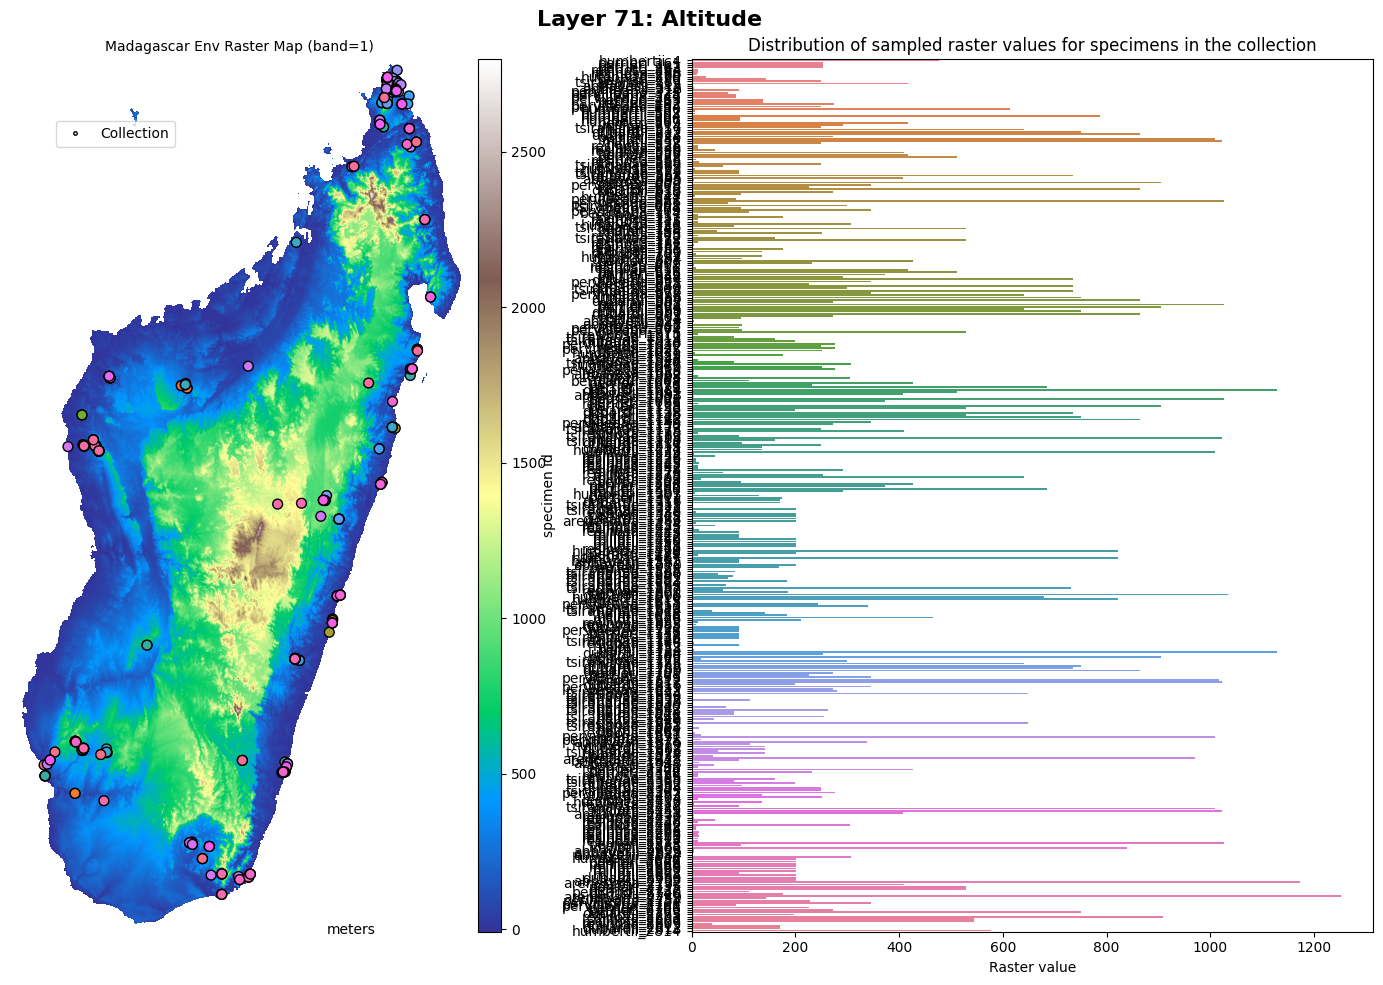

In [125]:
coll_no_caff_node_env.plot_on_layer(layer="layer_71", 
    imshow_cmap="terrain", 
    histplot_binwidth=100, histplot_stat="count", 
    subplots_figsize=(15, 10))

In [39]:

unique_values = df_w_caff['specimen_id'].unique()

# Print or work with the unique values
print(unique_values)


['C_humbertii_RNF785' 'C_perrieri_A12' 'C_pervilleana_A957'
 'C_tsirananae_A515' 'C_heimii_A516']


#MadaclimCollection points must have unique specimen_id

Creation of a Collection per species for visualisation

In [24]:

# df_2018_p.head()
#Extract all rows where any column contains the word 'heimii'

heimii_df = df_2018_p[df_2018_p.apply(lambda row: row.astype(str).str.contains('heimii', case=False).any(), axis=1)]

# Print or further manipulate the filtered DataFrame
print(heimii_df)


       genus_species  longitude   latitude    year   specimen_id
14672  Coffea heimii  49.263119 -12.279828  2020.0  heimii_14672
16490  Coffea heimii  49.347115 -12.210881  2020.0  heimii_16490
16893  Coffea heimii  49.303872 -12.318289  2020.0  heimii_16893
16895  Coffea heimii  49.226443 -12.281807  2020.0  heimii_16895
17832  Coffea heimii  49.342500 -12.396327  2019.0  heimii_17832
17834  Coffea heimii  49.275700 -12.398991  2019.0  heimii_17834
19479  Coffea heimii  49.569592 -12.454103  2019.0  heimii_19479
19555  Coffea heimii  49.549809 -12.580463  2019.0  heimii_19555


In [ ]:
def extract_rows_containing_word(df, word):
    filtered_df = df[df.apply(lambda row: row.astype(str).str.contains(word, case=False).any(), axis=1)]
    return filtered_df

In [42]:
heimii_df = extract_rows_containing_word(df_2018_p, "heimii")
print(heimii_df.shape)



(8, 5)


In [44]:
unique_values

humbertii_df = extract_rows_containing_word(df_2018_p, "humbertii")
perrieri_df = extract_rows_containing_word(df_2018_p, "perrieri")
pervilleana_df = extract_rows_containing_word(df_2018_p, "pervilleana")
tsirananae_df = extract_rows_containing_word(df_2018_p, "tsirananae")

print(humbertii_df.shape)
print(perrieri_df.shape)
print(pervilleana_df.shape)
print(tsirananae_df.shape)


(3, 5)
(22, 5)
(2, 5)
(10, 5)


In [13]:
from py_madaclim.raster_manipulation import MadaclimCollection

In [25]:
coll_heimii = MadaclimCollection.populate_from_df(heimii_df)

Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=heimii_14672...)
Creating MadaclimPoint(specimen_id=heimii_16490...)
Creating MadaclimPoint(specimen_id=heimii_16893...)
Creating MadaclimPoint(specimen_id=heimii_16895...)
Creating MadaclimPoint(specimen_id=heimii_17832...)
Creating MadaclimPoint(specimen_id=heimii_17834...)
Creating MadaclimPoint(specimen_id=heimii_19479...)
Creating MadaclimPoint(specimen_id=heimii_19555...)
Created new MadaclimCollection with 8 samples.


In [45]:
coll_humbertii = MadaclimCollection.populate_from_df(humbertii_df)
coll_perrieri = MadaclimCollection.populate_from_df(perrieri_df)
coll_pervilleana = MadaclimCollection.populate_from_df(pervilleana_df)
coll_tsirananae = MadaclimCollection.populate_from_df(tsirananae_df)

Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=humbertii_7021...)
Creating MadaclimPoint(specimen_id=humbertii J.-F.Leroy_8949...)
Creating MadaclimPoint(specimen_id=humbertii J.-F.Leroy_8951...)
Created new MadaclimCollection with 3 samples.
Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=perrieri Drake ex Jum. & H. Perrier_6802...)
Creating MadaclimPoint(specimen_id=perrieri Drake ex Jum. & H. Perrier_6858...)
Creating MadaclimPoint(specimen_id=perrieri Drake ex Jum. & H. Perrier_6916...)
Creating MadaclimPoint(specimen_id=perrieri_7584...)
Creating MadaclimPoint(specimen_id=perrieri Drake ex Jum. & H. Perrier_8151...)
Creating MadaclimPoint(specimen_id=perrieri_8546...)
Creating MadaclimPoint(specimen_id=perrieri_8666...)
Creating MadaclimPoint(specimen_id=perrieri Drake ex Jum. & H. Perrier_9136...)
Creating MadaclimPoint(specimen_id=perrieri Drak

In [46]:
coll_heimii.all_points[0]

MadaclimPoint(
	specimen_id = heimii_14672,
	source_crs = 4326,
	longitude = 49.263119,
	latitude = -12.279828,
	mada_geom_point = POINT (963987.2160799548 8638826.905155072),
	len(sampled_layers) = 79 layer(s),
	len(nodata_layers) = 8 layer(s),
	is_categorical_encoded = False,
	genus_species = Coffea heimii,
	year = 2020.0,
	gdf.shape = (1, 89)
)

Access the Geopandas dataframe attribute `gdf` based on the `mada_geom_point` geometry of each object

In [47]:
coll_heimii.gdf

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,genus_species,year,...,clim_70_ndm_Number of dry months in the year (months.year-1),env_71_alt_Altitude (meters),env_72_slo_Slope (degrees),env_73_asp_Aspect; clockwise from North (degrees),"env_74_solrad_Solar radiation; computed from altitude, slope and aspect (Wh.m-2.day-1)","env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)","env_76_soi_Soil types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23)","env_77_veg_Vegetation types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 22, 23, 25)","env_78_wat_Watersheds (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25)",env_79_forcov_Percentage of forest cover in 1 km by 1 km grid cells (%)
0,heimii_14672,4326,49.263119,-12.279828,POINT (963987.216 8638826.905),79,8,False,Coffea heimii,2020.0,...,9.0,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN,NaN
1,heimii_16490,4326,49.347115,-12.210881,POINT (973268.317 8646324.577),79,78,False,Coffea heimii,2020.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN,NaN
2,heimii_16893,4326,49.303872,-12.318289,POINT (968361.925 8634492.084),79,0,False,Coffea heimii,2020.0,...,9.0,71.0,6.0,85.0,7863.0,7.0,4.0,6,1.0,0.0
3,heimii_16895,4326,49.226443,-12.281807,POINT (959985.375 8638670.641),79,78,False,Coffea heimii,2020.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN,NaN
4,heimii_17832,4326,49.342500,-12.396327,POINT (972432.287 8625771.942),79,0,False,Coffea heimii,2019.0,...,8.0,141.0,7.0,246.0,7788.0,7.0,20.0,7,1.0,4.0
5,heimii_17834,4326,49.275700,-12.398991,POINT (965147.750 8625594.362),79,0,False,Coffea heimii,2019.0,...,8.0,184.0,3.0,313.0,7969.0,9.0,8.0,7,1.0,3.0
6,heimii_19479,4326,49.569592,-12.454103,POINT (997074.808 8618950.269),79,7,False,Coffea heimii,2019.0,...,8.0,NaN,NaN,NaN,NaN,NaN,4.0,25,NaN,NaN
7,heimii_19555,4326,49.549809,-12.580463,POINT (994676.992 8604973.911),79,0,False,Coffea heimii,2019.0,...,8.0,4.0,1.0,250.0,7880.0,2.0,4.0,3,1.0,64.0


### Sample from rasters

Just like the `MadaclimPoint` class, use the `sample_from_rasters` method to get data based on the collection's specimens.

In [29]:
from py_madaclim.info import MadaclimLayers
mada_info = MadaclimLayers()

In [31]:
print(mada_info.all_layers.shape)
mada_info.all_layers

(79, 6)


,geoclim_type,layer_number,layer_name,layer_description,is_categorical,units
0,clim,1,tmin1,Monthly minimum temperature - January,False,°C x 10
1,clim,2,tmin2,Monthly minimum temperature - February,False,°C x 10
2,clim,3,tmin3,Monthly minimum temperature - March,False,°C x 10
3,clim,4,tmin4,Monthly minimum temperature - April,False,°C x 10
4,clim,5,tmin5,Monthly minimum temperature - May,False,°C x 10
...,...,...,...,...,...,...
74,env,75,geo,Rock types,True,"[1=Alluvial_&_Lake_deposits, 2=Unconsolidated_..."
75,env,76,soi,Soil types,True,"[1=Bare_Rocks, 2=Raw_Lithic_Mineral_Soils, 3=P..."
76,env,77,veg,Vegetation types,True,"[1=VegCat_01, 2=VegCat_02, 3=VegCat_03, 4=VegC..."
77,env,78,wat,Watersheds,True,"[1=CoE_N-Bemarivo, 2=CoE_S-Bemarivo_N-Mangoro,..."


In [32]:
raster_files = ["madaclim_current.tif", "madaclim_enviro.tif"]
if not all([(cwd / raster_file).exists() for raster_file in raster_files]):
    mada_info.download_data(save_dir=cwd)



####   Trying get request to Madaclim website...   ####
madaclim_current.tif is 21.8 MB
Server response OK from madaclim.cirad.fr, starting to download madaclim_current.tif
Progress for madaclim_current.tif : 100.00 % completed of 21.8 MB downloaded [ average speed of  2.8 MB/s ]
Done downloading madaclim_current.tif in 7.67 seconds !

####   Trying get request to Madaclim website...   ####
madaclim_enviro.tif is 5.5 MB
Server response OK from madaclim.cirad.fr, starting to download madaclim_enviro.tif
Progress for madaclim_enviro.tif : 100.00 % completed of 5.5 MB downloaded [ average speed of  2.1 MB/s ]
Done downloading madaclim_enviro.tif in 2.70 seconds !


In [33]:

mada_info.clim_raster = "./madaclim_current.tif"
mada_info.env_raster = "./madaclim_enviro.tif"
print(mada_info)    # Now the 'get_bandnums_from_layers' is visible

MadaclimLayers(
	all_layers = DataFrame(79 rows x 6 columns)
	categorical_layers = DataFrame(Layers 75, 76, 77, 78 with a total of 79 categories
	clim_raster = madaclim_current.tif
	clim_crs = EPSG:32738
	env_raster = madaclim_enviro.tif
	env_crs = EPSG:32738
	public methods -> download_data, fetch_specific_layers, get_bandnums_from_layers
			 get_categorical_combinations, get_layers_labels, select_geoclim_type_layers
)


In [34]:
from py_madaclim.raster_manipulation import MadaclimRasters
from pathlib import Path
cwd = Path.cwd()
mada_rasters = MadaclimRasters(clim_raster=cwd / "madaclim_current.tif", env_raster=cwd / "madaclim_enviro.tif")
print(mada_rasters)

MadaclimRasters(
	clim_raster = madaclim_current.tif,
	clim_crs = EPSG:32738,
	clim_nodata_val = -32768.0
	env_raster = madaclim_enviro.tif,
	env_crs = EPSG:32738,
	env_nodata_val = -32768.0
)


In [56]:
coll_heimii.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster
)


######################################## Extracting data for: heimii_14672 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   


BEWARE! 8 layer(s) contain a nodata value at the specimen location

Finished raster sampling operation in 0.57 seconds.


######################################## Extracting data for: heimii_16490 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


...

BEWARE! 7 layer(s) contain a nodata value at the specimen location

Finished raster sampling operation in 0.52 seconds.


######################################## Extracting data for: heimii_19555 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.63 seconds.



In [57]:
coll_humbertii.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster
)

coll_perrieri.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster
)

coll_pervilleana.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster
)

coll_tsirananae.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster
)


######################################## Extracting data for: humbertii_7021 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   


BEWARE! 1 layer(s) contain a nodata value at the specimen location

Finished raster sampling operation in 0.63 seconds.


######################################## Extracting data for: humbertii J.-F.Leroy_8949 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


...


Finished raster sampling operation in 0.52 seconds.


######################################## Extracting data for: tsirananae_19273 ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   


BEWARE! 78 layer(s) contain a nodata value at the specimen location

Finished raster sampling operation in 0.54 seconds.



In [58]:
#mada_rasters.plot_layer(71);    # Also accepts layer="layer_71"
#coll_heimii.sampled_layers
coll_heimii.gdf


,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,genus_species,year,...,layer_70,layer_71,layer_72,layer_73,layer_74,layer_75,layer_76,layer_77,layer_78,layer_79
0,heimii_14672,4326,49.263119,-12.279828,POINT (963987.216 8638826.905),79,8,False,Coffea heimii,2020.0,...,9.0,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN,NaN
1,heimii_16490,4326,49.347115,-12.210881,POINT (973268.317 8646324.577),79,78,False,Coffea heimii,2020.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN,NaN
2,heimii_16893,4326,49.303872,-12.318289,POINT (968361.925 8634492.084),79,0,False,Coffea heimii,2020.0,...,9.0,71.0,6.0,85.0,7863.0,7.0,4.0,6,1.0,0.0
3,heimii_16895,4326,49.226443,-12.281807,POINT (959985.375 8638670.641),79,78,False,Coffea heimii,2020.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN,NaN
4,heimii_17832,4326,49.342500,-12.396327,POINT (972432.287 8625771.942),79,0,False,Coffea heimii,2019.0,...,8.0,141.0,7.0,246.0,7788.0,7.0,20.0,7,1.0,4.0
5,heimii_17834,4326,49.275700,-12.398991,POINT (965147.750 8625594.362),79,0,False,Coffea heimii,2019.0,...,8.0,184.0,3.0,313.0,7969.0,9.0,8.0,7,1.0,3.0
6,heimii_19479,4326,49.569592,-12.454103,POINT (997074.808 8618950.269),79,7,False,Coffea heimii,2019.0,...,8.0,NaN,NaN,NaN,NaN,NaN,4.0,25,NaN,NaN
7,heimii_19555,4326,49.549809,-12.580463,POINT (994676.992 8604973.911),79,0,False,Coffea heimii,2019.0,...,8.0,4.0,1.0,250.0,7880.0,2.0,4.0,3,1.0,64.0


In [94]:
bioclim_labels = [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "bio" in label]

In [50]:
# From the collection's objects
print(list(coll_heimii.sampled_layers.keys()))
for specimen_id in coll_heimii.sampled_layers:
    print(f"\nSampled layer values for {specimen_id}")
    for layer, value in coll_heimii.sampled_layers[specimen_id].items():
        if layer in bioclim_labels[0]:    #print only first bioclim layer
            print(f"{layer} => {value}")    
    

['heimii_14672', 'heimii_16490', 'heimii_16893', 'heimii_16895', 'heimii_17832', 'heimii_17834', 'heimii_19479', 'heimii_19555']

Sampled layer values for heimii_14672
clim_37_bio1_Annual mean temperature (degrees) => 264

Sampled layer values for heimii_16490
clim_37_bio1_Annual mean temperature (degrees) => nan

Sampled layer values for heimii_16893
clim_37_bio1_Annual mean temperature (degrees) => 266

Sampled layer values for heimii_16895
clim_37_bio1_Annual mean temperature (degrees) => nan

Sampled layer values for heimii_17832
clim_37_bio1_Annual mean temperature (degrees) => 257

Sampled layer values for heimii_17834
clim_37_bio1_Annual mean temperature (degrees) => 255

Sampled layer values for heimii_19479
clim_37_bio1_Annual mean temperature (degrees) => 265

Sampled layer values for heimii_19555
clim_37_bio1_Annual mean temperature (degrees) => 264


In [51]:
# Or from the geodataframe attribute
coll_heimii.gdf[["specimen_id"] + bioclim_labels[:1]]

,specimen_id,clim_37_bio1_Annual mean temperature (degrees)
0,heimii_14672,264.0
1,heimii_16490,NaN
2,heimii_16893,266.0
3,heimii_16895,NaN
4,heimii_17832,257.0
5,heimii_17834,255.0
6,heimii_19479,265.0
7,heimii_19555,264.0


exploring categorical data

In [52]:
categ_layers = mada_info.get_categorical_combinations(as_descriptive_keys=True)
print(list(categ_layers.keys())[0])

env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)


In [54]:
# No encoding
coll_heimii.gdf[["specimen_id"] + list(categ_layers.keys())]

,specimen_id,"env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)","env_76_soi_Soil types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23)","env_77_veg_Vegetation types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 22, 23, 25)","env_78_wat_Watersheds (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25)"
0,heimii_14672,NaN,NaN,25,NaN
1,heimii_16490,NaN,NaN,25,NaN
2,heimii_16893,7.0,4.0,6,1.0
3,heimii_16895,NaN,NaN,25,NaN
4,heimii_17832,7.0,20.0,7,1.0
5,heimii_17834,9.0,8.0,7,1.0
6,heimii_19479,NaN,4.0,25,NaN
7,heimii_19555,2.0,4.0,3,1.0


In [55]:
# Encoding categorical layers

# coll_heimii.binary_encode_categorical()
# print(coll_heimii.is_categorical_encoded)
# print(f"Shape of geodataframe post one-hot-encoding: {coll_heimii.gdf.shape}")

True
Shape of geodataframe post one-hot-encoding: (8, 168)


Default visualization for `MadaclimCollection` shows all the points on the specific raster map on the left and the actual values for each point on the right

c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: F

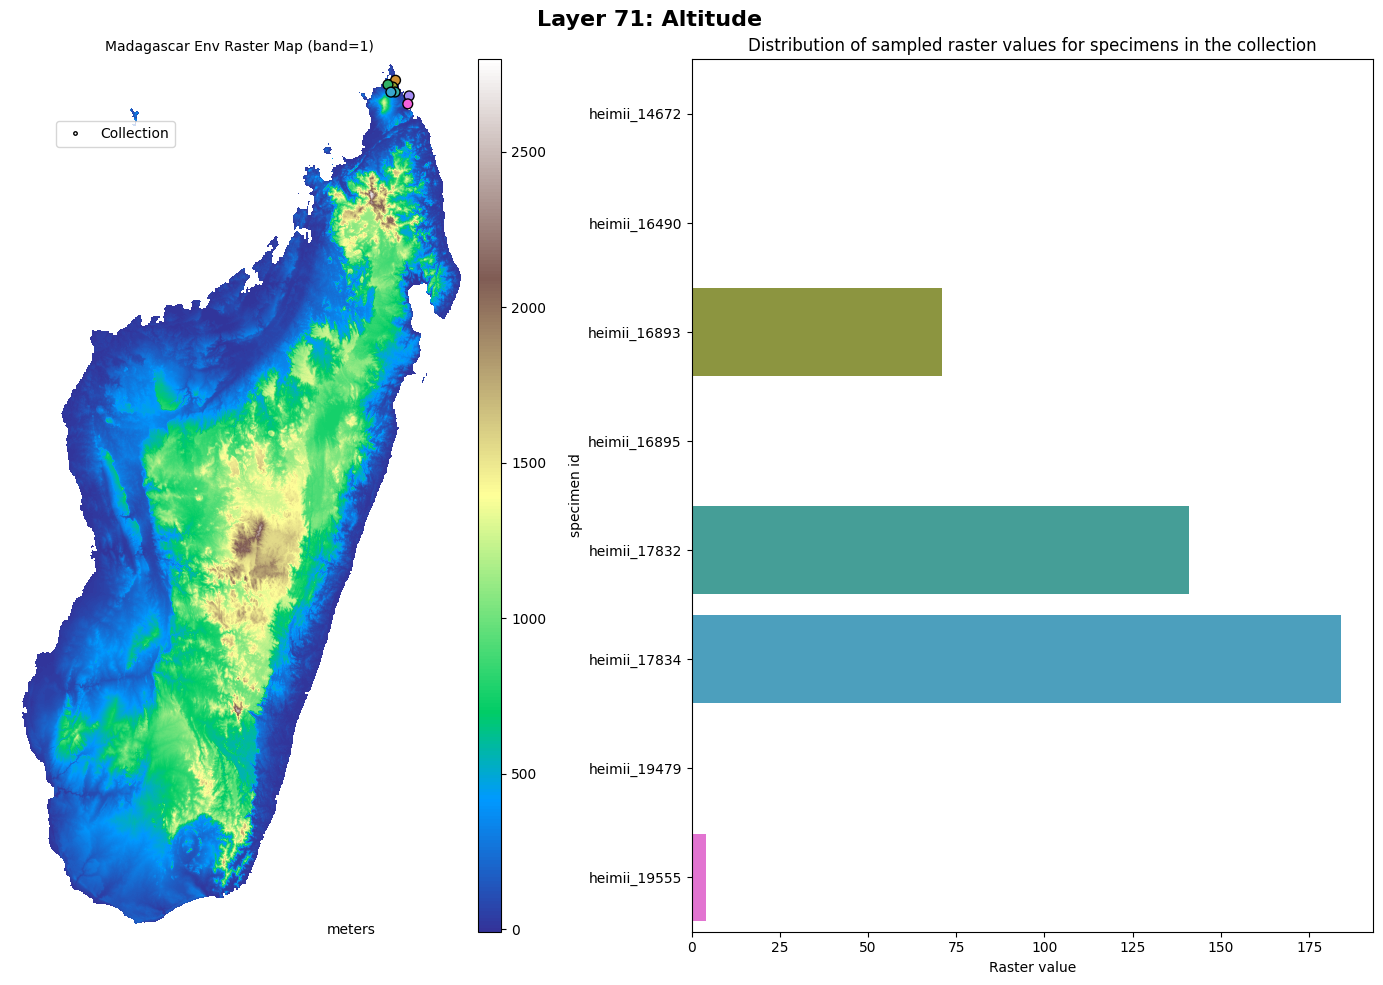

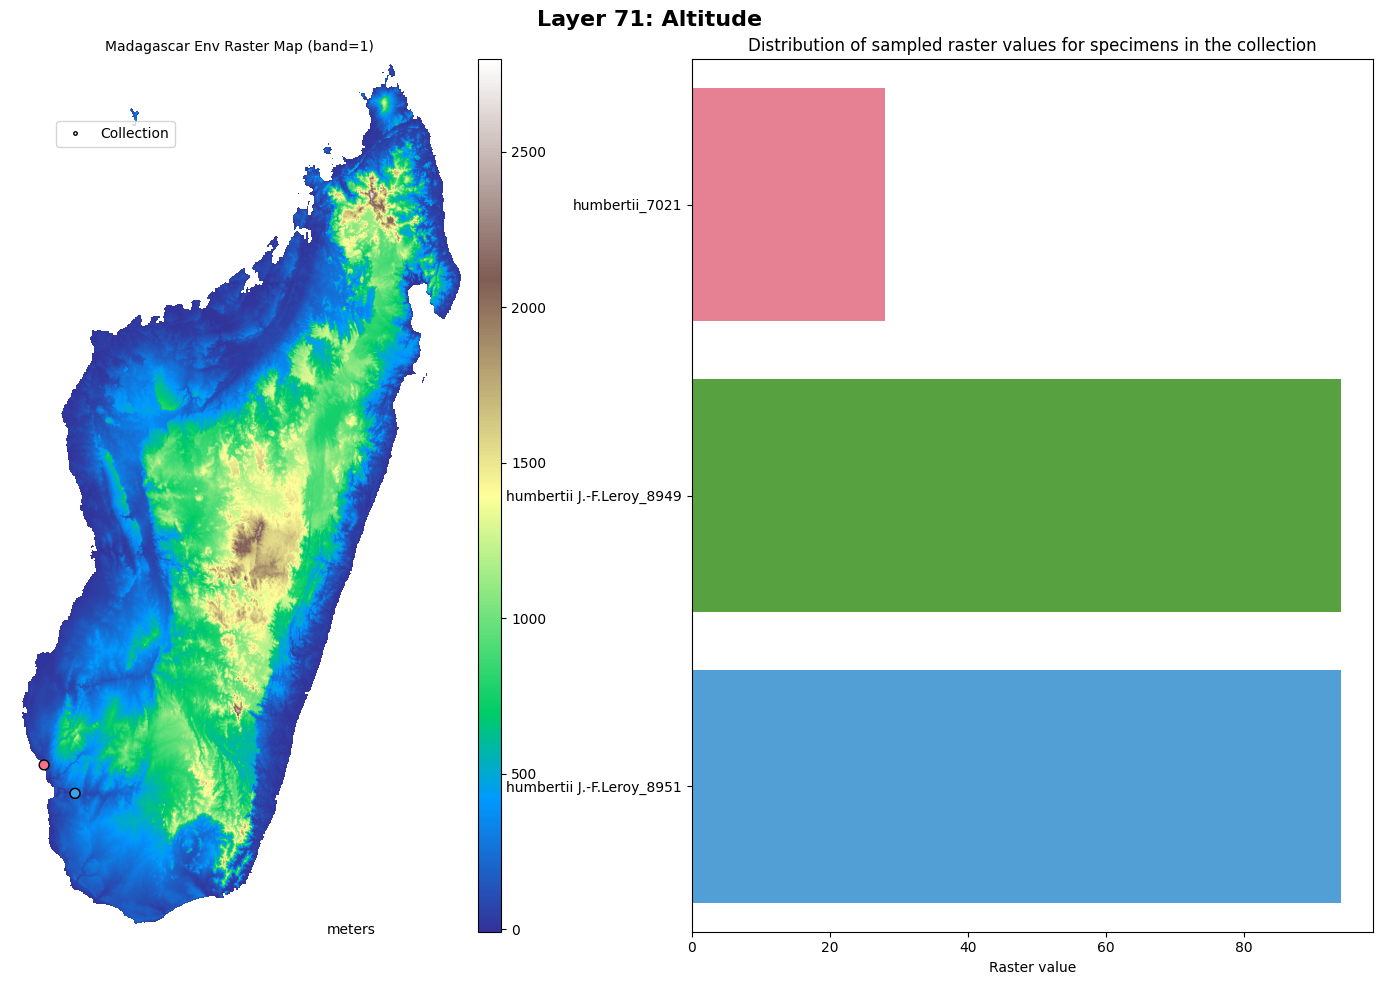

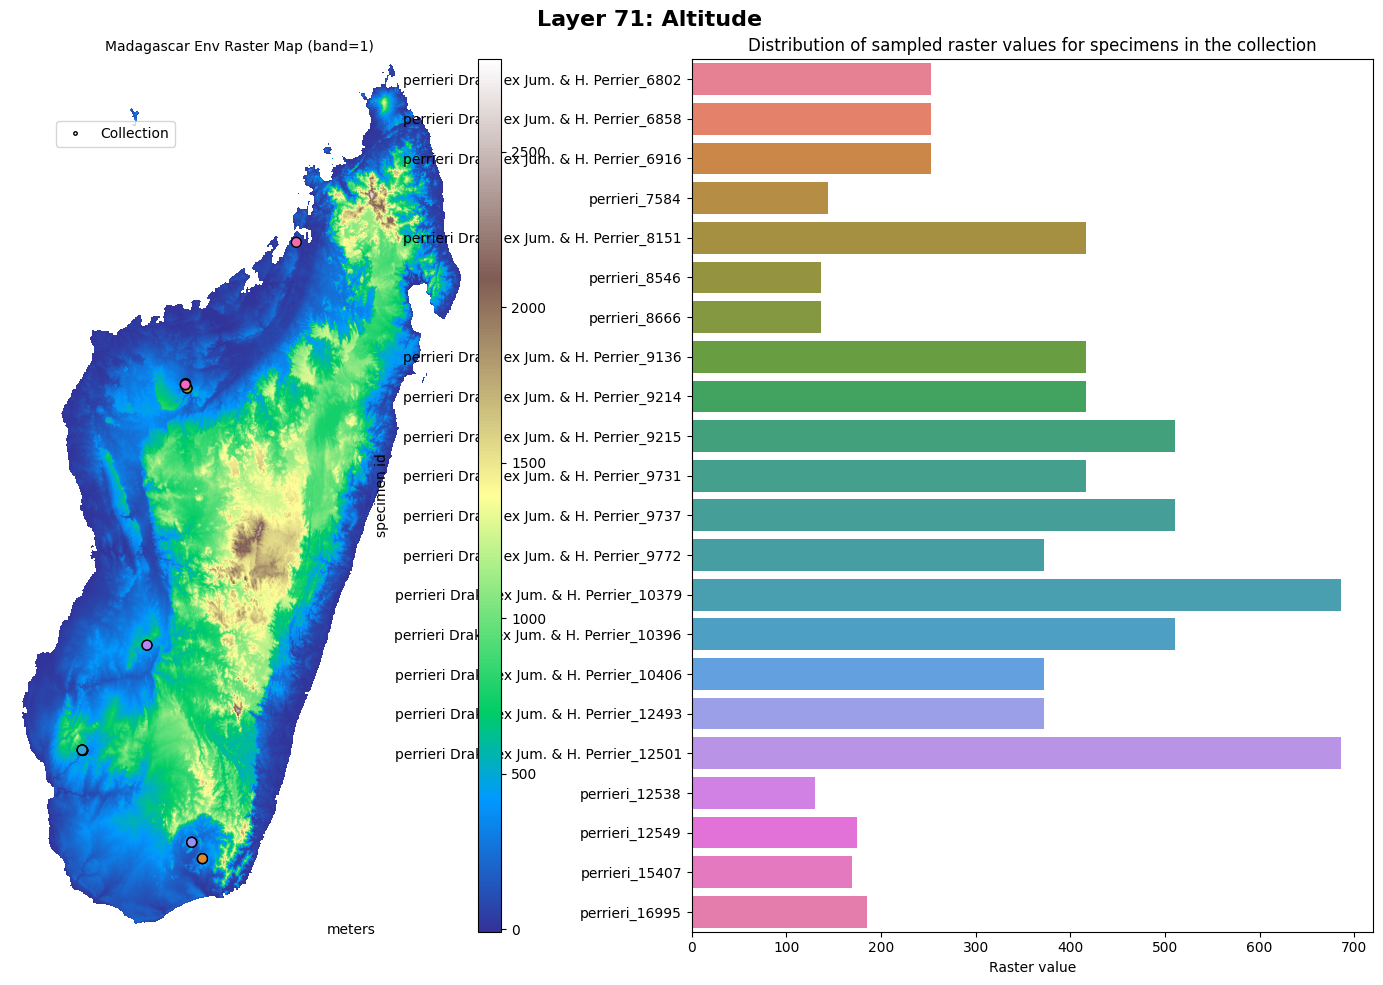

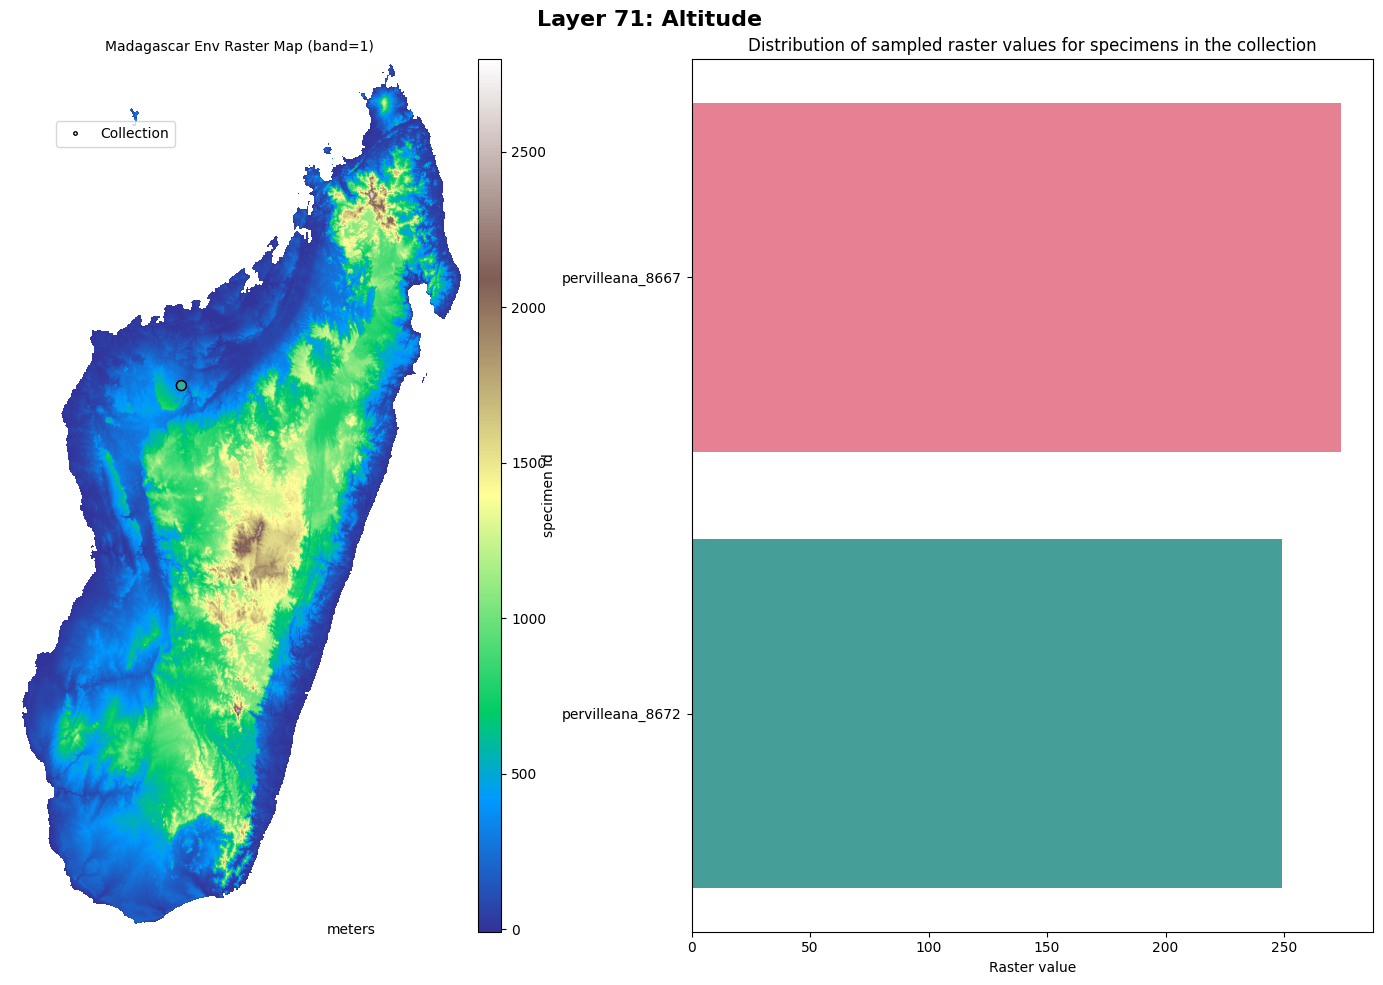

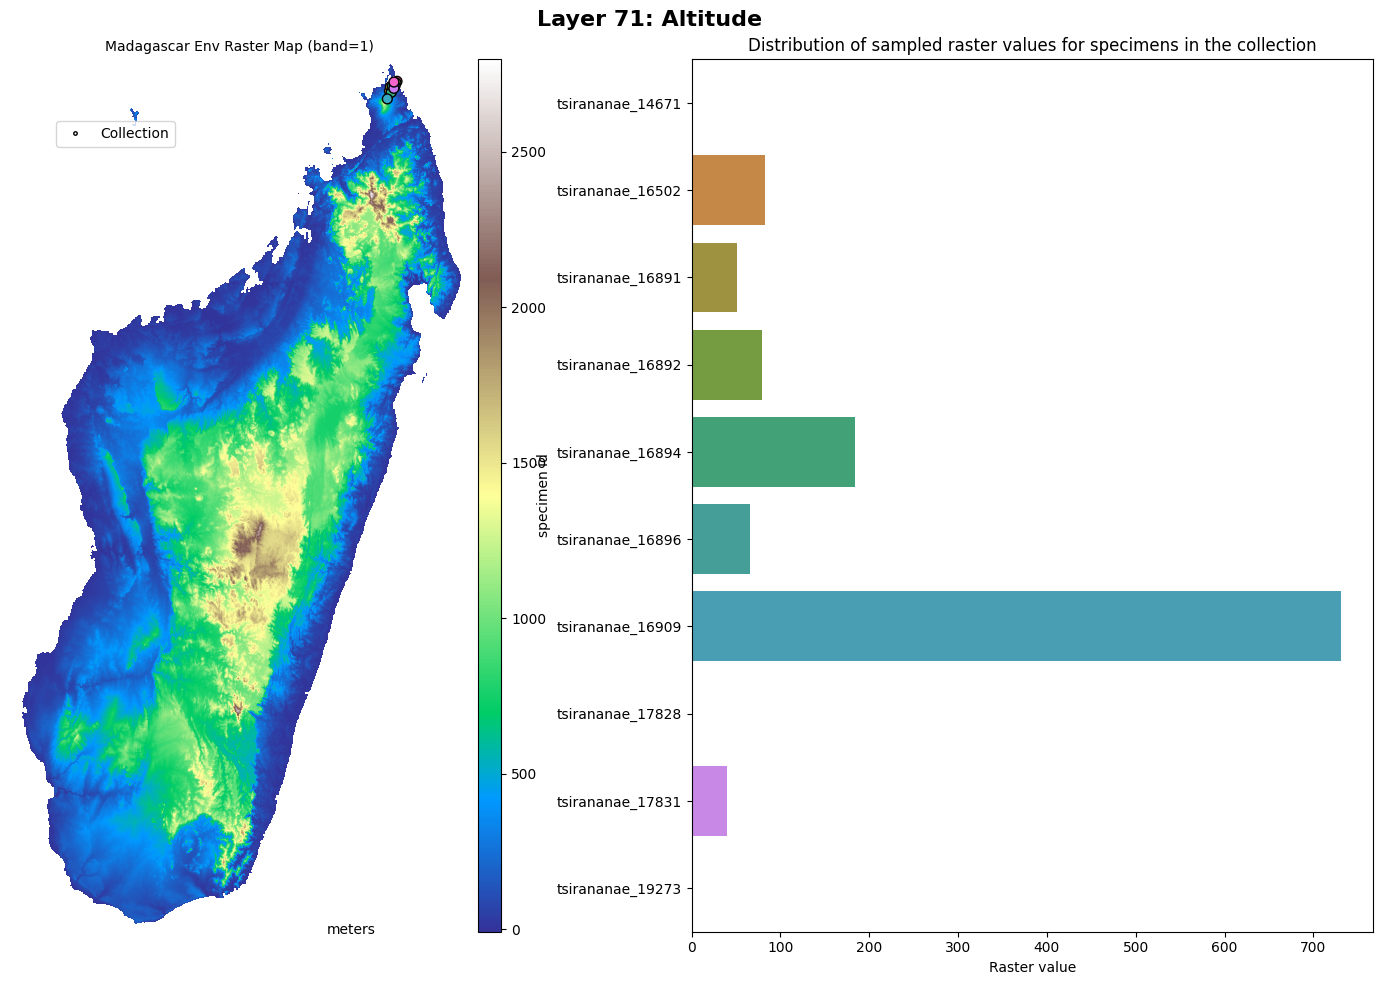

In [61]:
# Base visualization for continuous layers
def view_cont_layers(coll, layer_nb):
    coll_heimii.plot_on_layer(layer=layer_nb, 
        imshow_cmap="terrain", 
        histplot_binwidth=100, histplot_stat="count", 
        subplots_figsize=(15, 10))

view_cont_layers(coll_heimii, "layer_72")

coll_heimii.plot_on_layer(layer="layer_71", 
    imshow_cmap="terrain", 
    histplot_binwidth=100, histplot_stat="count", 
    subplots_figsize=(15, 10))

coll_humbertii.plot_on_layer(layer="layer_71", 
    imshow_cmap="terrain", 
    histplot_binwidth=100, histplot_stat="count", 
    subplots_figsize=(15, 10))

coll_perrieri.plot_on_layer(layer="layer_71", 
    imshow_cmap="terrain", 
    histplot_binwidth=100, histplot_stat="count", 
    subplots_figsize=(15, 10))

coll_pervilleana.plot_on_layer(layer="layer_71", 
    imshow_cmap="terrain", 
    histplot_binwidth=100, histplot_stat="count", 
    subplots_figsize=(15, 10))

coll_tsirananae.plot_on_layer(layer="layer_71", 
    imshow_cmap="terrain", 
    histplot_binwidth=100, histplot_stat="count", 
    subplots_figsize=(15, 10))



c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


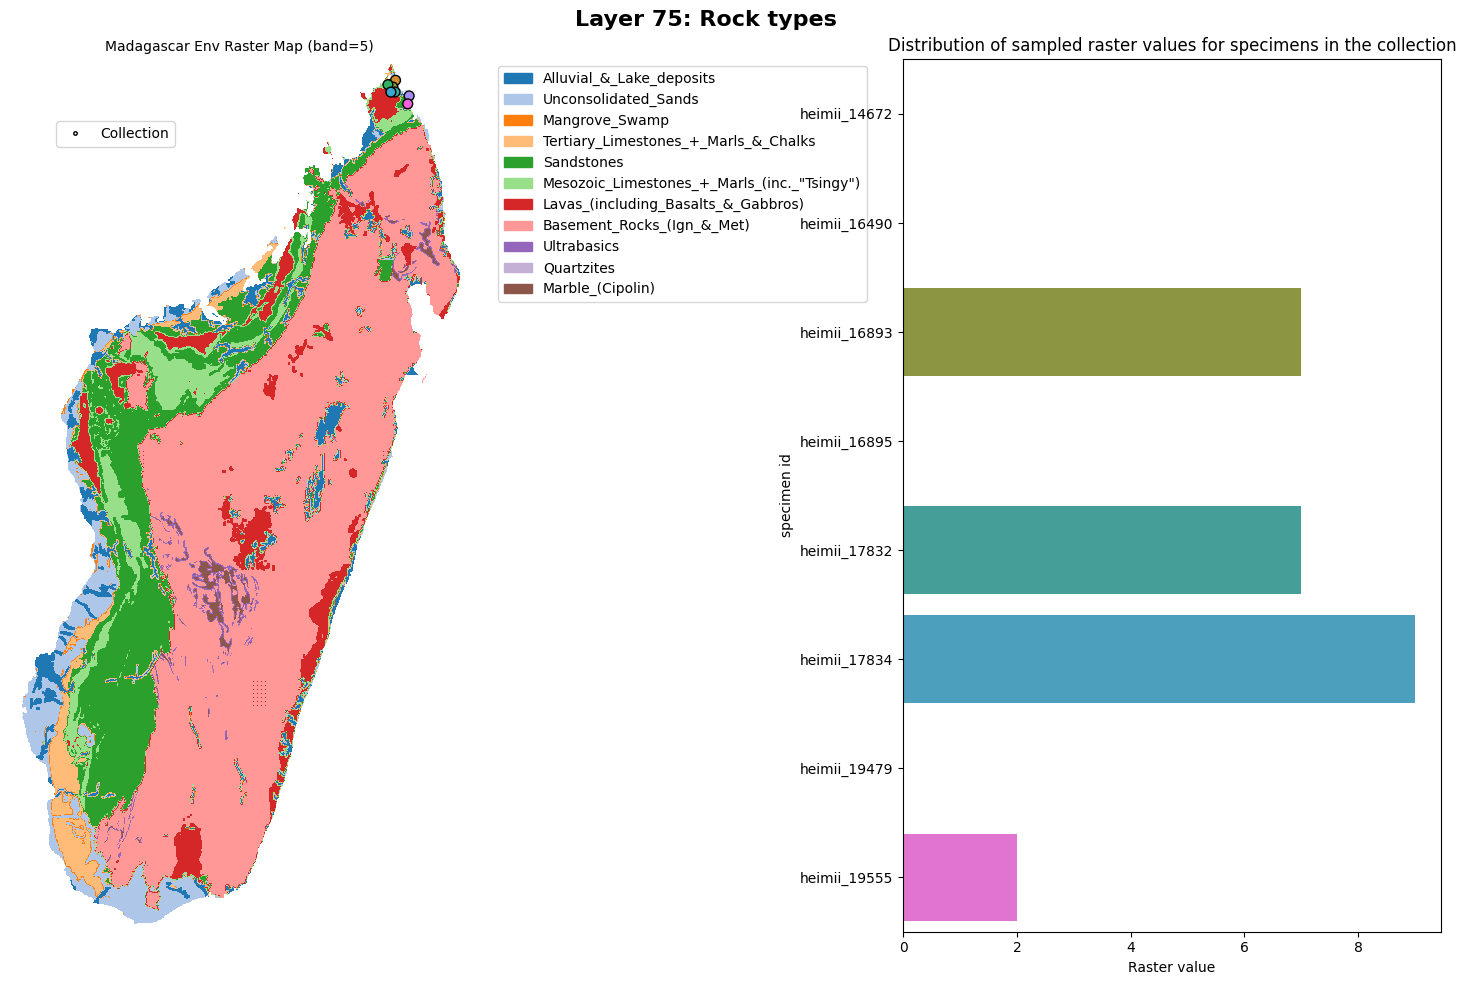

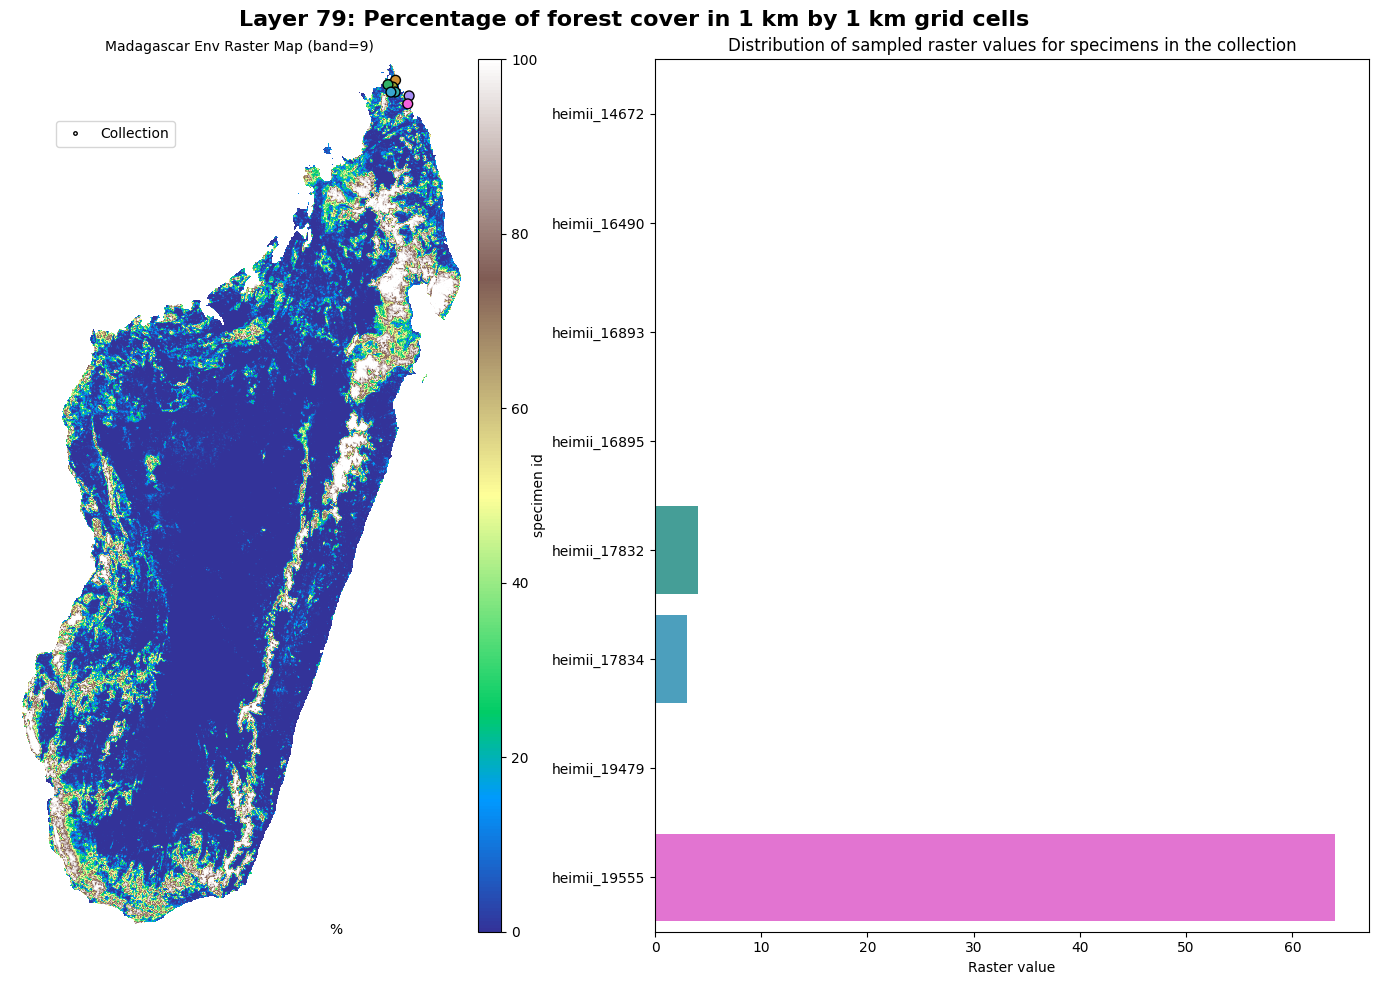

In [67]:
def view_cont_layers(coll, layer_nb):
    coll.plot_on_layer(layer=layer_nb, 
        imshow_cmap="terrain", 
        histplot_binwidth=100, histplot_stat="count", 
        subplots_figsize=(15, 10))

view_cont_layers(coll_heimii, "layer_75")

view_cont_layers(coll_heimii, "layer_79")

c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


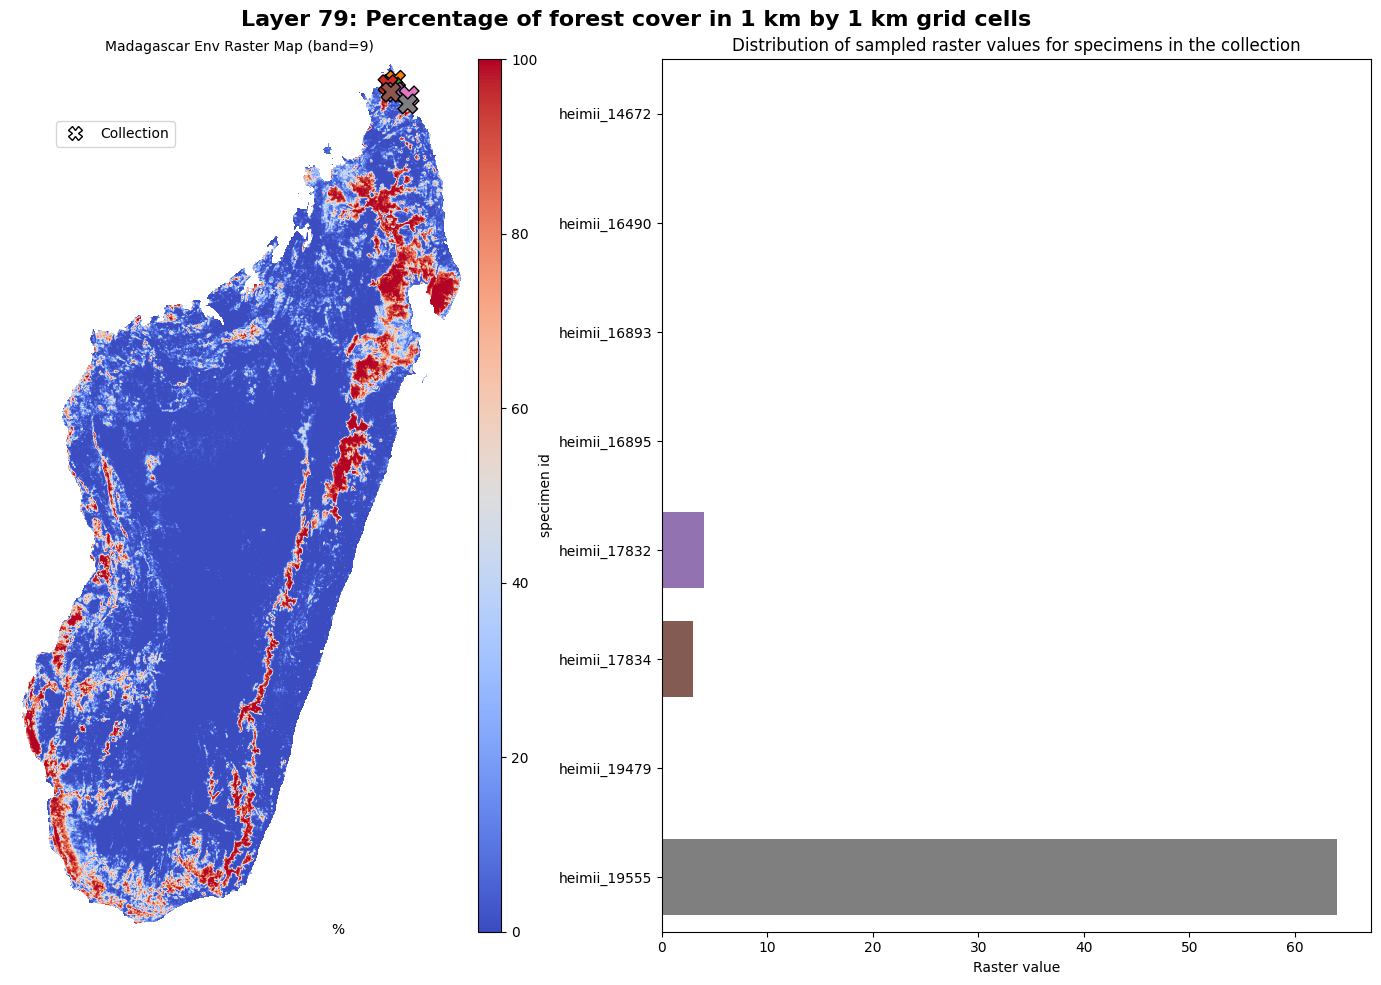

In [68]:
coll_heimii.plot_on_layer(
    layer="layer_79",
    subplots_figsize=(15, 10),
    imshow_cmap="coolwarm",
    rasterpoint_marker="X",
    rasterpoint_markersize=200,
    barplot_palette="tab10",    # Use either barplot_palette or rasterpoint_palette
    barplot_width=0.7,
)

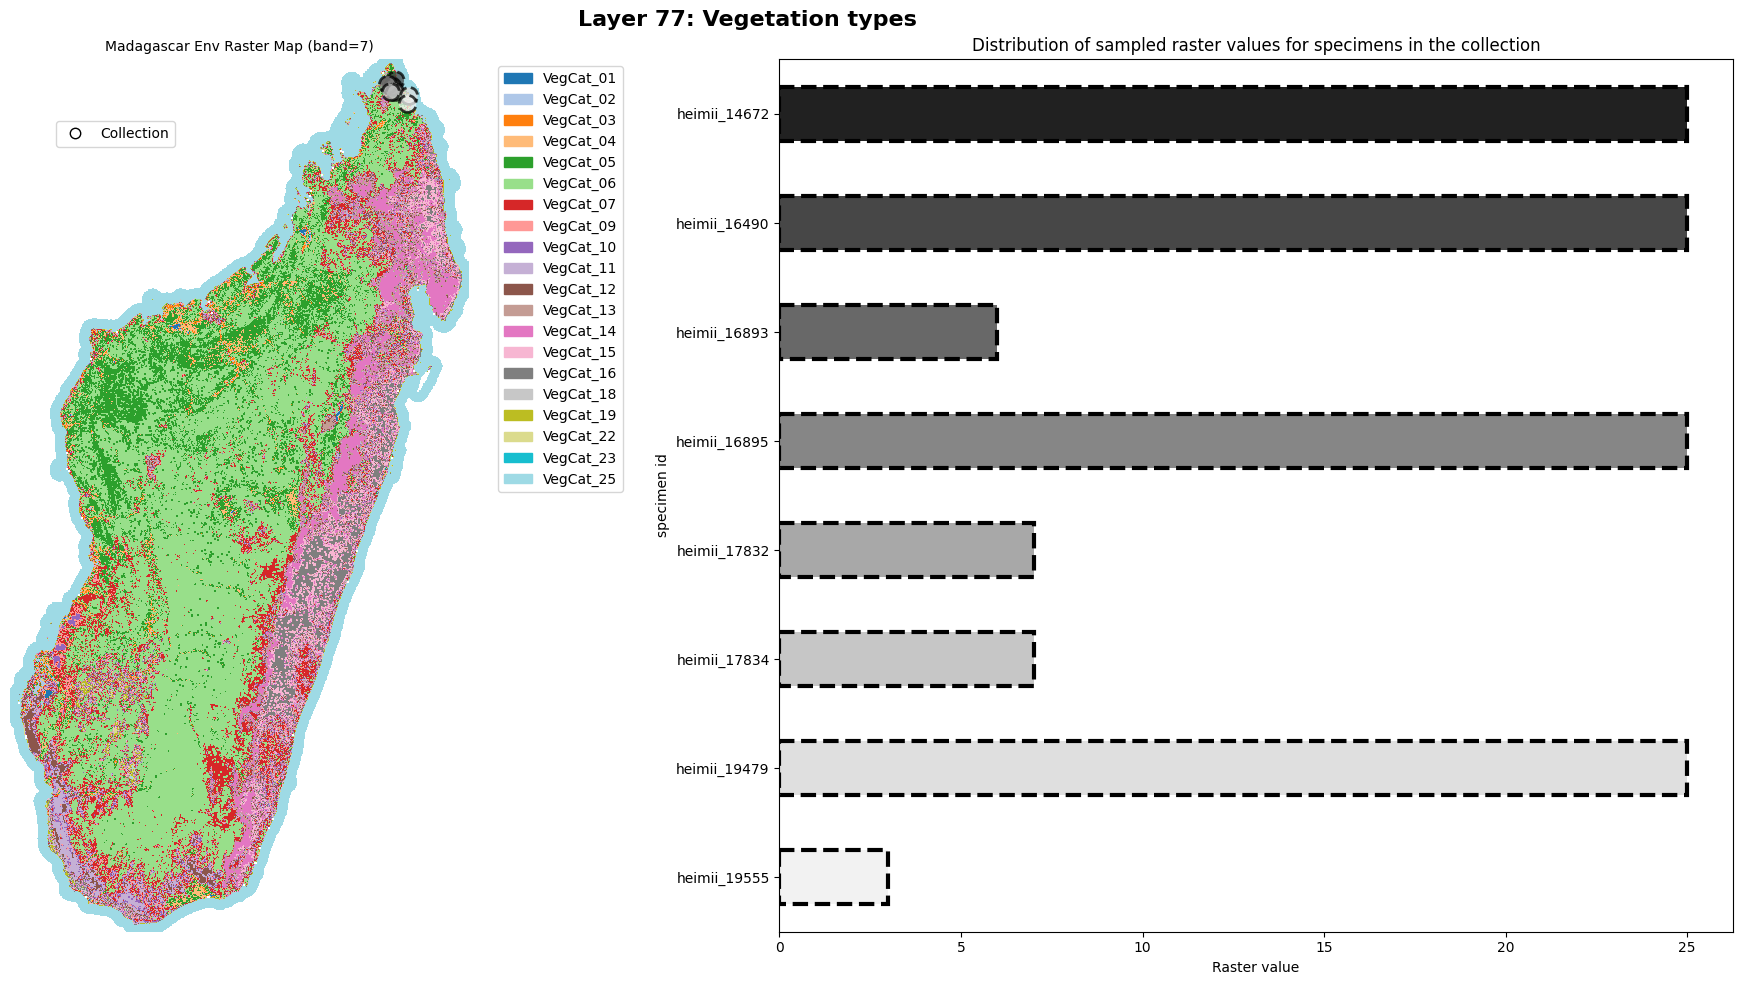

In [69]:
coll_heimii.plot_on_layer(
    layer="layer_77",
    rasterpoint_palette="Greys_r",
    rasterpoint_alpha=0.75,
    rasterpoint_markersize=150,
    rasterpoint_linewidths=2,
    rasterpoint_linestyle="--",
    barplot_linewidth=3,
    barplot_edgecolor="black",
    barplot_linestyle="--",
    barplot_width=0.5,
)